# Diabetes Prediction
### A Machine Learning Approach to Binary Clinical Classification

---

**Dataset:** Pima Indians Diabetes Dataset (768 patient records)  
**Task:** Binary Classification — Diabetic or Non-Diabetic        
  
--- 

### 1. Importing all the Liberies

In [313]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

### 2. Data Collection and Analysis

In [314]:
# Loading the Diabetes dataset to pandas dataframe
data = pd.read_csv("diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [315]:
# Number rows and columns in the dataset
data.shape

(768, 9)

In [316]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [317]:
# Statistical Information of the data
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 3. Data Cleaning

In this dataset, certain features contain `0` values that are **not biologically plausible**.  
For example, a glucose level or BMI of 0 is not possible in a living human.

Therefore, these `0` values are treated as **missing values** and handled accordingly during preprocessing.

**Affected Columns:**
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

**Approach:**
All `0` values in these columns are replaced with the **median** of the respective feature to maintain data integrity and avoid bias.


In [318]:
# Replacing missing values by median
cols = ['Glucose', 'BloodPressure','SkinThickness', 'Insulin', 'BMI']
for col in cols:
   data[col] = data[col].replace(0, data[col].median())

### 4. Exploratory Data Analysis (EDA)

Outcome Distribution

Outcome
0    500
1    268
Name: count, dtype: int64


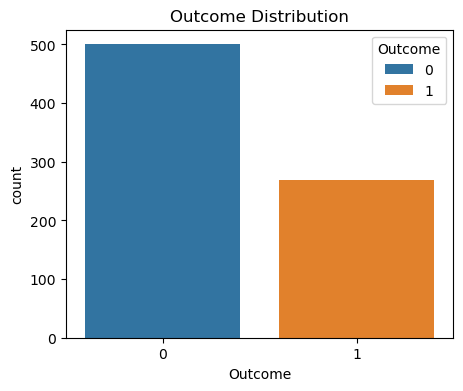

In [319]:
print(data["Outcome"].value_counts())
plt.figure(figsize=(5,4))
sns.countplot(x='Outcome', hue ='Outcome', data=data)
plt.title("Outcome Distribution")
plt.show()

Distribution plots for all numeric(continuous) features

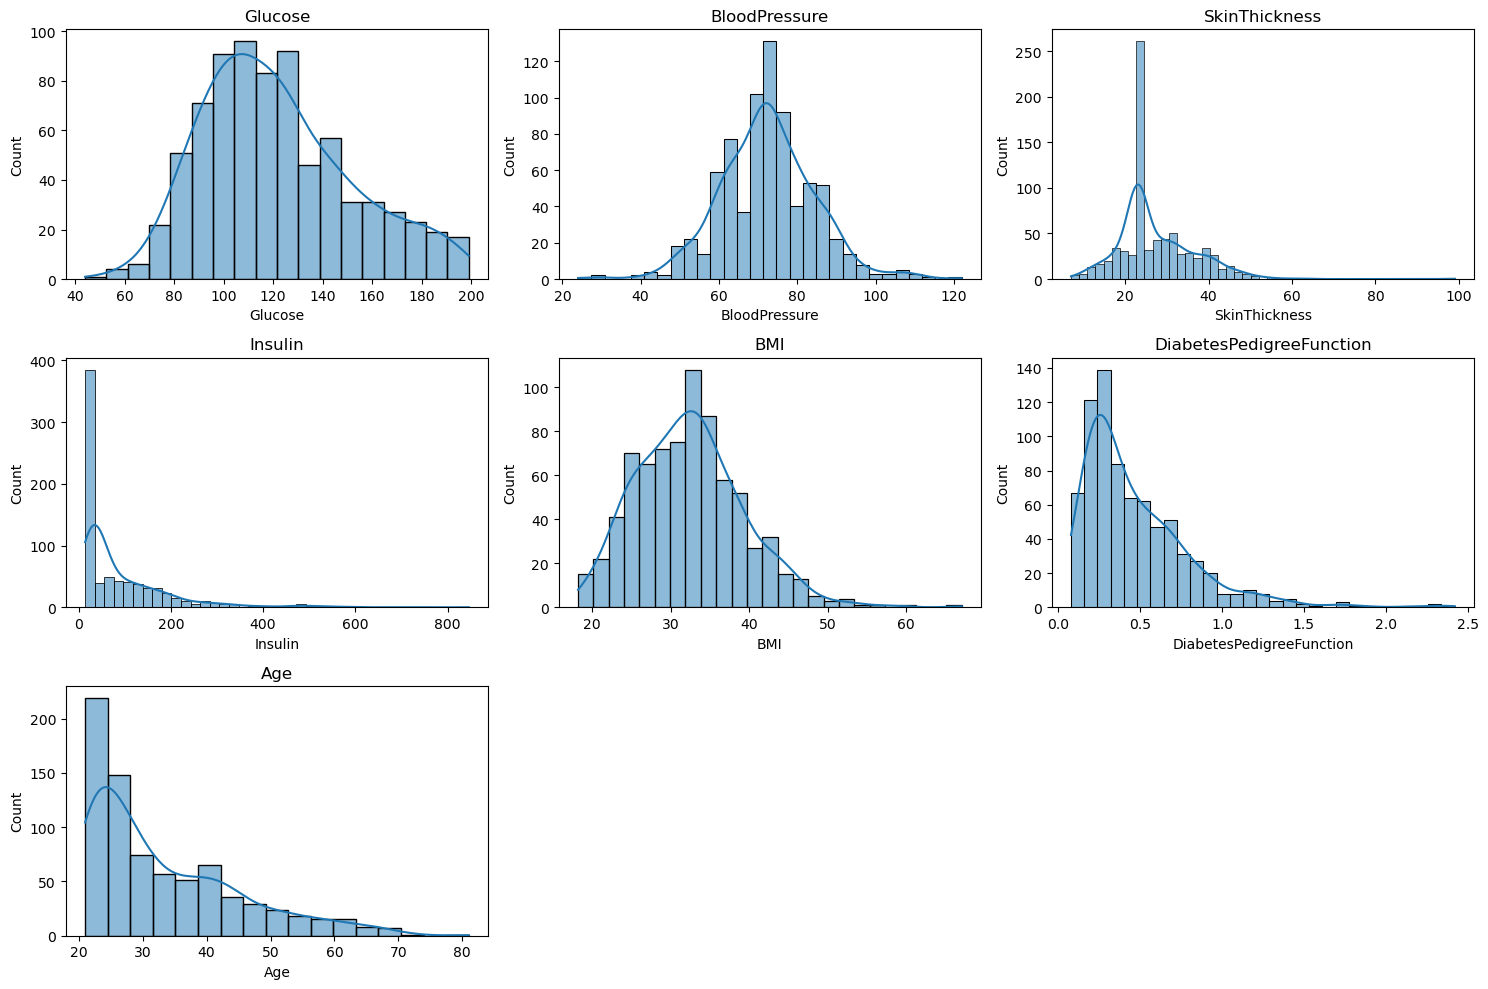

In [320]:

# List of columns (excluding target)
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

Distribution with respect to Outcome

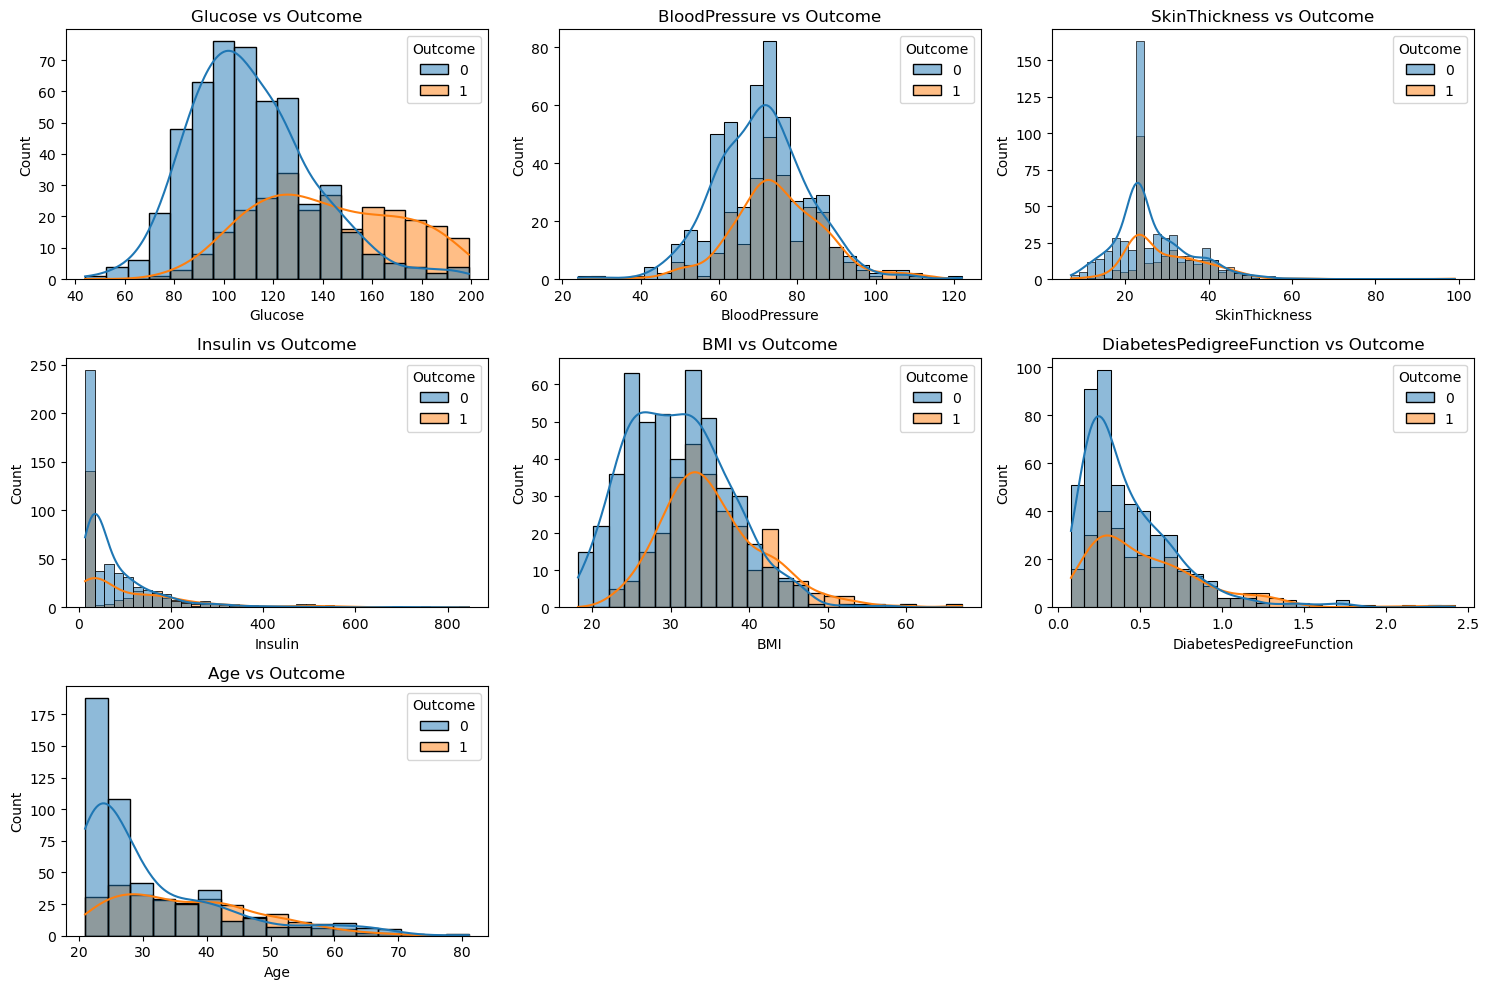

In [321]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data=data, x=col, hue='Outcome', kde=True)
    plt.title(col + " vs Outcome")

plt.tight_layout()
plt.show()

Pregnancies(discrete) plot

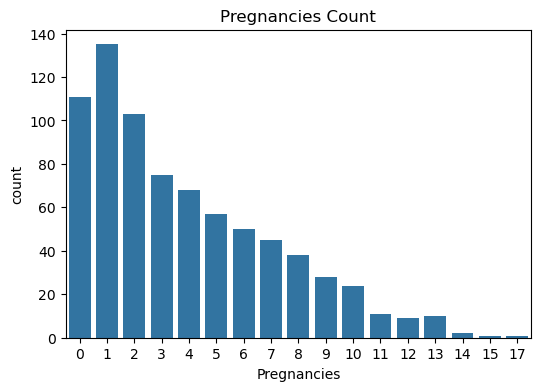

In [322]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pregnancies', data=data)
plt.title("Pregnancies Count")
plt.show()

Pregnancies vs Outcome

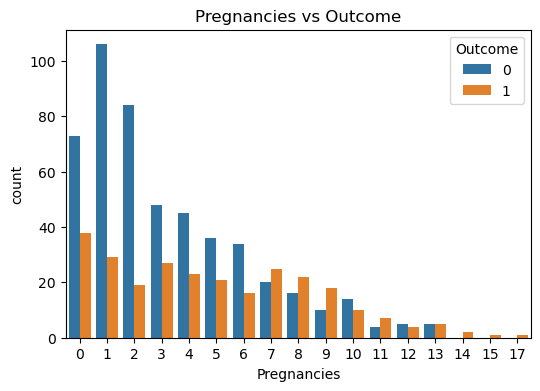

In [323]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pregnancies', hue='Outcome', data=data)
plt.title("Pregnancies vs Outcome")
plt.show()

Correlation Heatmap

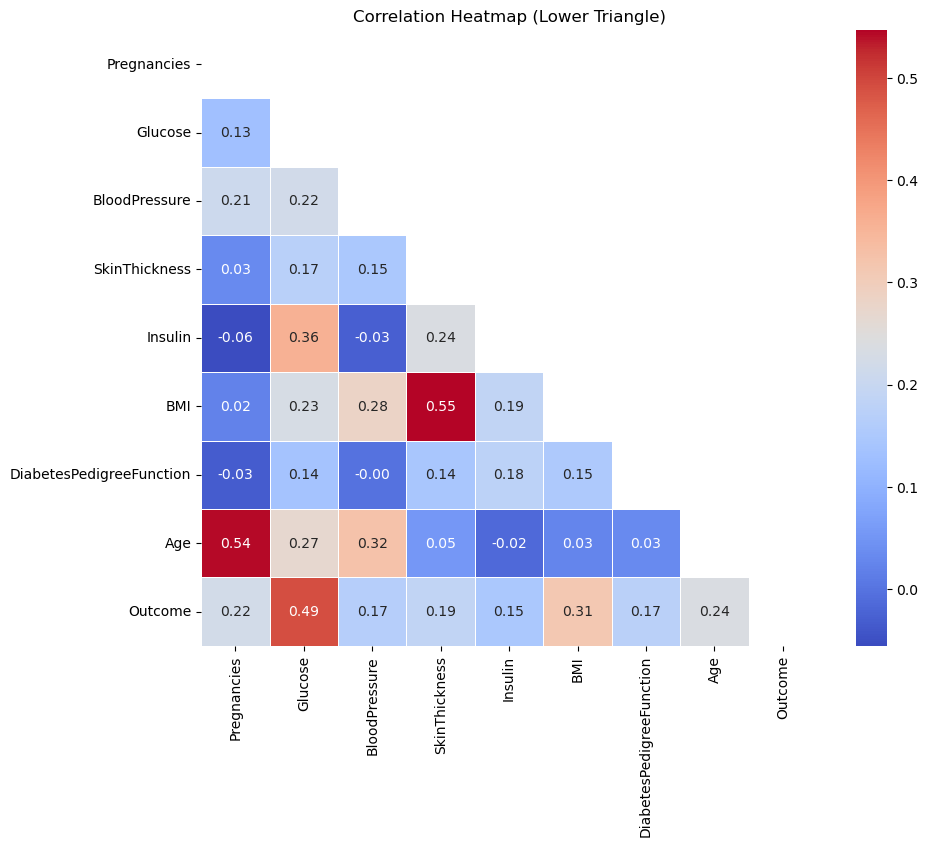

In [324]:
import numpy as np

corr = data.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap (Lower Triangle)")
plt.show()

Here we see that 'Glucose' and 'BMI' are highly correlated with the Outcome.

### 5. Feature and target split

In [325]:
# Seperating Data and lebels
X = data.drop(columns = "Outcome", axis = 1)
y = data["Outcome"]


In [326]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35     30.5  33.6   
1              1       85             66             29     30.5  26.6   
2              8      183             64             23     30.5  23.3   
3              1       89             66             23     94.0  28.1   
4              0      137             40             35    168.0  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48    180.0  32.9   
764            2      122             70             27     30.5  36.8   
765            5      121             72             23    112.0  26.2   
766            1      126             60             23     30.5  30.1   
767            1       93             70             31     30.5  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [327]:
print(y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


### 6. Train Test Split

In [328]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=101
)

### 7. Build Pipeline (Scaling + Model)

In [329]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel= 'linear'))
])

### 8. K-Fold Cross Validation

In [330]:
scores = cross_val_score(pipeline, X_train, y_train, cv=5)
print(scores.mean())

0.7612136377854238


### 9. Train Final Model

In [331]:
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'


### 10 Model Evaluation

Accuracy: 0.8311688311688312
---Confusion Matrix---
[[49  4]
 [ 9 15]]


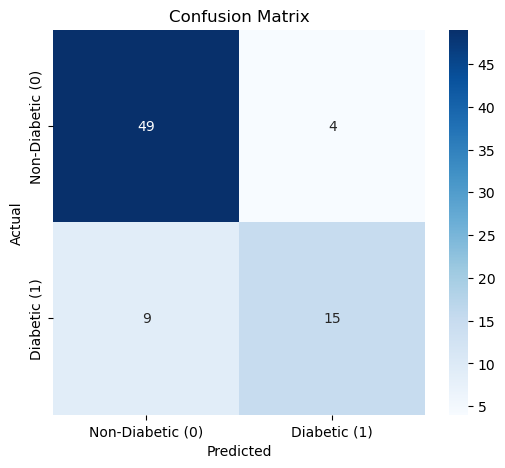

In [332]:
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("---Confusion Matrix---")

cm = confusion_matrix(y_test, y_pred)   
print(cm)                               

labels = ['Non-Diabetic (0)', 'Diabetic (1)']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### 11. Conclusion
This project developed a machine learning model to predict diabetes using the PIMA dataset. Data preprocessing revealed the presence of invalid zero values in key medical features, which were handled to improve data quality. Exploratory analysis showed moderate correlations between features and the outcome, providing initial insight into feature relevance. The model achieved an accuracy of 83.12%, correctly classifying 49 non-diabetic and 15 diabetic cases. However, 9(Actual = Diabetic, Predicted = Non-diabetic) diabetic cases were misclassified.                            

Limitation: The dataset is relatively small and may suffer from class imbalance, which affects generalization. The use of a linear SVM limits the model’s ability to capture complex, non-linear relationships. 